In [13]:
import warnings
warnings.filterwarnings('ignore')

import os, copy, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint

In [14]:
# --- Seed sabitleme ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# --- Genel hiperparametreler ---
DATA_PATH   = "C:/Users/kerem/Desktop/EnerjiSon/claude/birlesik_veri.csv"
LOOKBACK_TUKETIM = 72   # tüketim için mevcut değer yeterli
LOOKBACK_FIYAT   = 168  # ✅ yeni: 7 günlük haftalık pencere
HORIZON     = 24    # 1 günlük tahmin ufku (saat)
BATCH_SIZE  = 512
MAX_EPOCHS  = 60
PATIENCE    = 12    # early stopping için
LR          = 1e-3
WEIGHT_DECAY= 1e-4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {DEVICE}")

Kullanılan cihaz: cpu


VERİ YÜKLEME VE ÖN İŞLEME

In [15]:
def load_and_engineer(path: str, target: str, min_year: int = None) -> pd.DataFrame:
    """
    Ham CSV'yi yükler, özellik mühendisliği uygular.

    Özellikler:
      - Döngüsel zaman kodlaması (saat, gün, ay → sin/cos)
      - Hedef lag özellikleri: 24h, 48h, 168h  (veri sızıntısı yok, shift ile)
      - Rolling istatistikler: 24h & 168h pencere
      - Hava durumu gecikmesi: sicaklik_lag24

    min_year: Fiyat modeli için 2022'den itibaren başlat
              (2021 fiyat rejimi ~5x düşük → yapısal kırılma)
    """
    df = pd.read_csv(path)
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df = df.sort_values('Datetime').reset_index(drop=True)

    # Fiyat rejim filtresi
    if min_year:
        df = df[df['Datetime'].dt.year >= min_year].reset_index(drop=True)

    # --- Döngüsel kodlama ---
    df['saat_sin'] = np.sin(2 * np.pi * df['saat'] / 24)
    df['saat_cos'] = np.cos(2 * np.pi * df['saat'] / 24)
    df['gun_sin']  = np.sin(2 * np.pi * df['haftanin_gunu'] / 7)
    df['gun_cos']  = np.cos(2 * np.pi * df['haftanin_gunu'] / 7)
    df['ay_sin']   = np.sin(2 * np.pi * df['ay'] / 12)
    df['ay_cos']   = np.cos(2 * np.pi * df['ay'] / 12)

    # --- Hedef lag / rolling (geçmişe dayalı, sızıntısız) ---
    for lag in [24, 48, 168]:
        df[f'{target}_lag{lag}'] = df[target].shift(lag)

    df[f'{target}_roll24_mean']  = df[target].shift(1).rolling(24).mean()
    df[f'{target}_roll24_std']   = df[target].shift(1).rolling(24).std()
    df[f'{target}_roll168_mean'] = df[target].shift(1).rolling(168).mean()

    # Hava durumu gecikmesi (tahmin sırasında önceki gün verisi mevcut)
    df['sicaklik_lag24'] = df['sicaklik'].shift(24)

    df = df.dropna().reset_index(drop=True)
    df['time_idx'] = np.arange(len(df))
    df['group']    = 'TR_elektrik'   # TFT grup kimliği

    return df

def time_split(df, val_year=2024, test_year=2025):
    train = df[df['Datetime'].dt.year <  val_year].copy()
    val   = df[df['Datetime'].dt.year == val_year].copy()
    test  = df[df['Datetime'].dt.year >= test_year].copy()
    return train, val, test


def apply_price_clip(df_fiyat: pd.DataFrame,
                     val_year: int = 2024,
                     test_year: int = 2025,
                     quantile: float = 0.99) -> tuple:
    """
    ✅ clip_upper'ı train setinden hesaplar ve SPLIT'TEN ÖNCE uygular.
    Döner: (train_f, val_f, test_f) — hepsi kırpılmış fiyat içerir.

    Neden önemli:
      Kırpılmamış spike'lar (örn. 10,000+ TL) RobustScaler'ı
      olumsuz etkiler, kayıp fonksiyonunu domine eder ve CNN-LSTM'nin
      genel bölgelerdeki hassasiyetini azaltır.
    """
    # Geçici train-only split → clip sınırını öğrenmek için
    temp_train = df_fiyat[df_fiyat['Datetime'].dt.year < val_year]
    clip_upper  = temp_train['fiyat_tl'].quantile(quantile)

    print(f"  Fiyat clip eşiği (%{quantile*100:.0f}): {clip_upper:,.1f} TL/MWh")
    n_clipped = (df_fiyat['fiyat_tl'] > clip_upper).sum()
    print(f"  Kırpılan gözlem: {n_clipped:,} ({n_clipped/len(df_fiyat)*100:.2f}%)")

    # ✅ Kırpılmış sütun yeni DataFrame'e yaz
    df_clipped = df_fiyat.copy()
    df_clipped['fiyat_tl'] = df_clipped['fiyat_tl'].clip(upper=clip_upper)

    # Şimdi split yap — alt DataFrame'ler kırpılmış değerleri içeriyor
    train_f, val_f, test_f = time_split(df_clipped, val_year, test_year)
    return train_f, val_f, test_f

df_tuketim = load_and_engineer(DATA_PATH, 'tuketim_mwh', min_year=None)
df_fiyat   = load_and_engineer(DATA_PATH, 'fiyat_tl',    min_year=2022)

print(f"Tüketim verisi: {df_tuketim.shape}  "
      f"({df_tuketim['Datetime'].dt.year.min()}–{df_tuketim['Datetime'].dt.year.max()})")
print(f"Fiyat verisi  : {df_fiyat.shape}   "
      f"({df_fiyat['Datetime'].dt.year.min()}–{df_fiyat['Datetime'].dt.year.max()})")

Tüketim verisi: (43656, 30)  (2021–2025)
Fiyat verisi  : (34896, 30)   (2022–2025)


Özellik Grupları & Train / Val / Test Ayrımı

In [16]:
WEATHER_FEATURES  = ['sicaklik', 'hissedilen_sicaklik', 'nem',
                     'bulut_ortus', 'ruzgar_hizi', 'yagis', 'sicaklik_lag24']
CYCLICAL_FEATURES = ['saat_sin', 'saat_cos', 'gun_sin', 'gun_cos', 'ay_sin', 'ay_cos']
BINARY_FEATURES   = ['is_weekend', 'is_holiday']

def get_feature_cols(target: str) -> list:
    lag_cols = [
        f'{target}_lag24',       f'{target}_lag48',      f'{target}_lag168',
        f'{target}_roll24_mean', f'{target}_roll24_std', f'{target}_roll168_mean',
    ]
    return WEATHER_FEATURES + CYCLICAL_FEATURES + BINARY_FEATURES + lag_cols

train_t, val_t, test_t = time_split(df_tuketim)
train_f, val_f, test_f = apply_price_clip(df_fiyat)  # ← kırpma içinde

print(f"\nTüketim → Train: {len(train_t):,}  Val: {len(val_t):,}  Test: {len(test_t):,}")
print(f"Fiyat   → Train: {len(train_f):,}  Val: {len(val_f):,}  Test: {len(test_f):,}")

  Fiyat clip eşiği (%99): 4,823.3 TL/MWh
  Kırpılan gözlem: 174 (0.50%)

Tüketim → Train: 26,112  Val: 8,784  Test: 8,760
Fiyat   → Train: 17,352  Val: 8,784  Test: 8,760


Normalizasyon

In [17]:
def fit_scalers(train_df, target, feature_cols):
    sx = RobustScaler().fit(train_df[feature_cols].values)
    sy = RobustScaler().fit(train_df[[target]].values)
    return sx, sy


feat_t = get_feature_cols('tuketim_mwh')
feat_f = get_feature_cols('fiyat_tl')

scaler_X_t, scaler_y_t = fit_scalers(train_t, 'tuketim_mwh', feat_t)
scaler_X_f, scaler_y_f = fit_scalers(train_f, 'fiyat_tl',    feat_f)

print(f"\nÖzellik sayısı → Tüketim: {len(feat_t)}  Fiyat: {len(feat_f)}")


Özellik sayısı → Tüketim: 21  Fiyat: 21


PyTorch Dataset (kayan pencere)

In [18]:
class ElectricityDataset(Dataset):
    def __init__(self, df, target, feature_cols, scaler_X, scaler_y,
                 lookback=72, horizon=HORIZON):   # ← LOOKBACK değil, 72 sabit değer
        X_sc = scaler_X.transform(df[feature_cols].values).astype(np.float32)
        y_sc = scaler_y.transform(df[[target]].values).flatten().astype(np.float32)

        self.X        = torch.from_numpy(X_sc)
        self.y        = torch.from_numpy(y_sc)
        self.lookback = lookback
        self.horizon  = horizon
        self.n        = len(df) - lookback - horizon + 1

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        x_seq = self.X[i : i + self.lookback]
        y_seq = self.y[i + self.lookback : i + self.lookback + self.horizon]
        return x_seq, y_seq


def make_loaders(dfs, target, feature_cols, sx, sy,
                 lookback=72, shuffle_train=True):
    """
    DÜZELTİLMİŞ: num_workers=2 (Jupyter'da güvenli değer)
    """
    train_df, val_df, test_df = dfs

    def _ds(df):
        return ElectricityDataset(df, target, feature_cols, sx, sy, lookback=lookback)

    def _dl(ds, shuffle):
        return DataLoader(
            ds, batch_size=BATCH_SIZE, shuffle=shuffle,
            num_workers=0,        # ← DÜZELTİLDİ: os.cpu_count() yerine 2
            pin_memory=True,
            drop_last=False
        )

    return (_dl(_ds(train_df), shuffle_train),
            _dl(_ds(val_df),   False),
            _dl(_ds(test_df),  False))


loader_train_t, loader_val_t, loader_test_t = make_loaders(
    (train_t, val_t, test_t), 'tuketim_mwh', feat_t, scaler_X_t, scaler_y_t, lookback=LOOKBACK_TUKETIM)

loader_train_f, loader_val_f, loader_test_f = make_loaders(
    (train_f, val_f, test_f), 'fiyat_tl', feat_f, scaler_X_f, scaler_y_f, lookback=LOOKBACK_FIYAT)

CNN-LSTM MİMARİSİ

In [19]:
class CNNLSTM(nn.Module):
    """
    CNN Encoder → LSTM Temporal Modeler → FC Decoder

    Overfitting önleme:
      - BatchNorm1d (covariate shift azaltma)
      - Dropout (encoder + decoder'da)
      - Gradient clipping (eğitimde)
      - Weight Decay / AdamW (optimizer'da)
      - Huber Loss (outlier'lara karşı dayanıklı)
    """
    def __init__(self, n_features: int, n_filters: int = 64,
                 kernel_size: int = 3, lstm_hidden: int = 128,
                 lstm_layers: int = 2, dropout: float = 0.25,
                 horizon: int = HORIZON):
        super().__init__()

        # --- CNN Encoder ---
        self.encoder = nn.Sequential(
            # Katman 1
            nn.Conv1d(n_features, n_filters,     kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(n_filters),
            nn.GELU(),
            nn.Dropout(dropout),
            # Katman 2
            nn.Conv1d(n_filters, n_filters * 2,  kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(n_filters * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            # Katman 3 — yerel örüntüleri daha geniş perdesiz yakala
            nn.Conv1d(n_filters * 2, n_filters * 2, kernel_size=5, padding=2),
            nn.BatchNorm1d(n_filters * 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.6),
        )

        # --- LSTM Temporal Modeler ---
        self.lstm = nn.LSTM(
            input_size=n_filters * 2,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        # --- Attention over LSTM outputs (lightweight) ---
        self.attn = nn.Sequential(
            nn.Linear(lstm_hidden, 1),
            nn.Tanh(),
        )

        # --- FC Decoder ---
        self.decoder = nn.Sequential(
            nn.Linear(lstm_hidden, 64),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, horizon),
        )

    def forward(self, x):
        # x : (B, T, F)
        h = x.permute(0, 2, 1)            # (B, F, T)
        h = self.encoder(h)               # (B, n_filters*2, T)
        h = h.permute(0, 2, 1)            # (B, T, n_filters*2)

        out, _ = self.lstm(h)             # (B, T, lstm_hidden)

        # Soft attention üzerinden ağırlıklı toplam
        w = torch.softmax(self.attn(out), dim=1)   # (B, T, 1)
        context = (w * out).sum(dim=1)             # (B, lstm_hidden)

        return self.decoder(context)               # (B, horizon)

In [20]:
class EarlyStopper:
    def __init__(self, patience=PATIENCE, min_delta=1e-5):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None

    def step(self, val_loss, model) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
            return False          # eğitime devam
        self.counter += 1
        return self.counter >= self.patience   # True → dur

In [21]:
def train_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total += loss.item() * len(X)
    return total / len(loader.dataset)

In [22]:
@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        total += criterion(model(X), y).item() * len(X)
    return total / len(loader.dataset)

In [23]:
def train_cnnlstm(model, loader_tr, loader_val, label="model"):
    """
    DÜZELTİLMİŞ:
    1. model.load_state_dict(stopper.best_state) eklendi
    2. return model, history eklendi (hist_t, hist_f için)
    3. AdamW weight_decay düzeltildi
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=2, eta_min=1e-5)
    criterion = nn.HuberLoss(delta=1.0)
    stopper   = EarlyStopper(PATIENCE)

    history = {'train': [], 'val': []}
    model.to(DEVICE)

    print(f"\n{'='*55}")
    print(f"  CNN-LSTM [{label}] eğitimi başlıyor  |  device: {DEVICE}")
    print(f"{'='*55}")

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss  = train_epoch(model, loader_tr, optimizer, criterion)
        val_loss = eval_epoch(model, loader_val, criterion)
        scheduler.step()

        history['train'].append(tr_loss)
        history['val'].append(val_loss)

        if epoch % 5 == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:3d}/{MAX_EPOCHS}  "
                  f"Train: {tr_loss:.5f}  Val: {val_loss:.5f}  LR: {lr_now:.6f}")

        if stopper.step(val_loss, model):
            print(f"  → Early stopping  (epoch {epoch},  best val: {stopper.best_loss:.5f})")
            break

    # ← DÜZELTİLDİ: En iyi ağırlıkları geri yükle
    model.load_state_dict(stopper.best_state)
    model.eval()

    print(f"  [{label}] Eğitim tamamlandı. Best val loss: {stopper.best_loss:.5f}")

    # ← DÜZELTİLDİ: history de döndürülüyor
    return model, history

CNN-LSTM Eğitimi

In [24]:
cnnlstm_tuketim = CNNLSTM(n_features=len(feat_t))
cnnlstm_fiyat = CNNLSTM(n_features=len(feat_f), dropout=0.40)      # 0.25 → 0.40

cnnlstm_tuketim, hist_t = train_cnnlstm(
    CNNLSTM(n_features=len(feat_t)).to(DEVICE),
    loader_train_t, loader_val_t, label="Tüketim"
)

cnnlstm_fiyat, hist_f = train_cnnlstm(
    CNNLSTM(n_features=len(feat_f)).to(DEVICE),
    loader_train_f, loader_val_f, label="Fiyat"
)


  CNN-LSTM [Tüketim] eğitimi başlıyor  |  device: cpu
  Epoch   1/60  Train: 0.16402  Val: 0.17424  LR: 0.000994
  Epoch   5/60  Train: 0.05123  Val: 0.04595  LR: 0.000855
  Epoch  10/60  Train: 0.01633  Val: 0.03110  LR: 0.000505
  Epoch  15/60  Train: 0.01332  Val: 0.02480  LR: 0.000155
  Epoch  20/60  Train: 0.01263  Val: 0.02592  LR: 0.001000
  Epoch  25/60  Train: 0.01143  Val: 0.02316  LR: 0.000962
  Epoch  30/60  Train: 0.00969  Val: 0.02413  LR: 0.000855
  Epoch  35/60  Train: 0.00867  Val: 0.02271  LR: 0.000694
  Epoch  40/60  Train: 0.00793  Val: 0.02390  LR: 0.000505
  Epoch  45/60  Train: 0.00761  Val: 0.02219  LR: 0.000316
  → Early stopping  (epoch 45,  best val: 0.02012)
  [Tüketim] Eğitim tamamlandı. Best val loss: 0.02012

  CNN-LSTM [Fiyat] eğitimi başlıyor  |  device: cpu
  Epoch   1/60  Train: 0.25757  Val: 0.17965  LR: 0.000994
  Epoch   5/60  Train: 0.17888  Val: 0.17865  LR: 0.000855
  Epoch  10/60  Train: 0.16010  Val: 0.19637  LR: 0.000505
  → Early stopping  

In [25]:
@torch.no_grad()
def evaluate_by_horizon(model, loader, scaler_y, label="", device=DEVICE):
    """
    Her tahmin ufku adımı için ayrı RMSE/MAE/sMAPE hesaplar.
    NRMSE oran (0..1) olarak döner — *100 yapılmaz.
    """
    model.eval()
    preds_all, trues_all = [], []

    for X, y in loader:
        p = model(X.to(device)).cpu().numpy()
        preds_all.append(p)
        trues_all.append(y.numpy())

    preds = np.concatenate(preds_all)   # (N, horizon)
    trues = np.concatenate(trues_all)   # (N, horizon)

    def inv(arr):
        flat = arr.reshape(-1, 1)
        return scaler_y.inverse_transform(flat).reshape(arr.shape)

    preds_inv = inv(preds)
    trues_inv = inv(trues)

    horizon = preds_inv.shape[1]

    print(f"\n[{label}] Horizon başına RMSE:")
    print(f"  {'Adım':>4} {'RMSE':>10} {'MAE':>10} {'sMAPE%':>8}")
    print(f"  {'─'*4} {'─'*10} {'─'*10} {'─'*8}")

    for h in range(horizon):
        yt = trues_inv[:, h]
        yp = preds_inv[:, h]
        rmse  = np.sqrt(mean_squared_error(yt, yp))
        mae   = mean_absolute_error(yt, yp)
        smape = 100 * np.mean(
            2 * np.abs(yp - yt) / (np.abs(yt) + np.abs(yp) + 1e-8)
        )
        print(f"  h={h:>2} {rmse:>10.1f} {mae:>10.1f} {smape:>8.2f}%")

    rmse_all  = np.sqrt(mean_squared_error(trues_inv.ravel(), preds_inv.ravel()))
    mae_all   = mean_absolute_error(trues_inv.ravel(), preds_inv.ravel())
    smape_all = 100 * np.mean(
        2 * np.abs(preds_inv - trues_inv)
        / (np.abs(preds_inv) + np.abs(trues_inv) + 1e-8)
    )
    # DÜZELTME: * 100 kaldırıldı → oran formunda döner
    nrmse_all = rmse_all / (trues_inv.max() - trues_inv.min() + 1e-8)

    print(f"\n  Genel  RMSE:{rmse_all:>10.1f}  MAE:{mae_all:>10.1f}"
          f"  sMAPE:{smape_all:>7.2f}%  NRMSE:{nrmse_all:.4f}  (={nrmse_all*100:.2f}%)")

    return {
        "preds": preds_inv, "trues": trues_inv,
        "RMSE": rmse_all, "MAE": mae_all,
        "sMAPE": smape_all,
        "NRMSE": nrmse_all,   # 0..1 arası oran (% DEĞİL)
    }


print("\n=== CNN-LSTM Test Sonuçları ===")
res_t = evaluate_by_horizon(cnnlstm_tuketim, loader_test_t, scaler_y_t, "Tüketim (MWh)")
res_f = evaluate_by_horizon(cnnlstm_fiyat,   loader_test_f, scaler_y_f, "Fiyat   (TL) ")


=== CNN-LSTM Test Sonuçları ===

[Tüketim (MWh)] Horizon başına RMSE:
  Adım       RMSE        MAE   sMAPE%
  ──── ────────── ────────── ────────
  h= 0     1844.8     1355.3     3.41%
  h= 1     1864.0     1359.8     3.41%
  h= 2     1865.7     1358.1     3.40%
  h= 3     1867.4     1353.6     3.39%
  h= 4     1876.9     1357.9     3.40%
  h= 5     1871.8     1354.2     3.40%
  h= 6     1866.6     1348.3     3.40%
  h= 7     1878.7     1357.2     3.42%
  h= 8     1919.4     1392.8     3.50%
  h= 9     1944.8     1407.9     3.54%
  h=10     1958.5     1409.1     3.54%
  h=11     1990.6     1433.4     3.60%
  h=12     2007.4     1444.8     3.62%
  h=13     1993.9     1433.7     3.60%
  h=14     2008.3     1453.5     3.66%
  h=15     2013.7     1458.0     3.67%
  h=16     2028.1     1463.4     3.69%
  h=17     2025.9     1456.5     3.67%
  h=18     2022.9     1445.2     3.65%
  h=19     2044.4     1467.2     3.71%
  h=20     2064.8     1481.8     3.74%
  h=21     2074.6     1483.7     3

Eğitim Geçmişi Grafiği

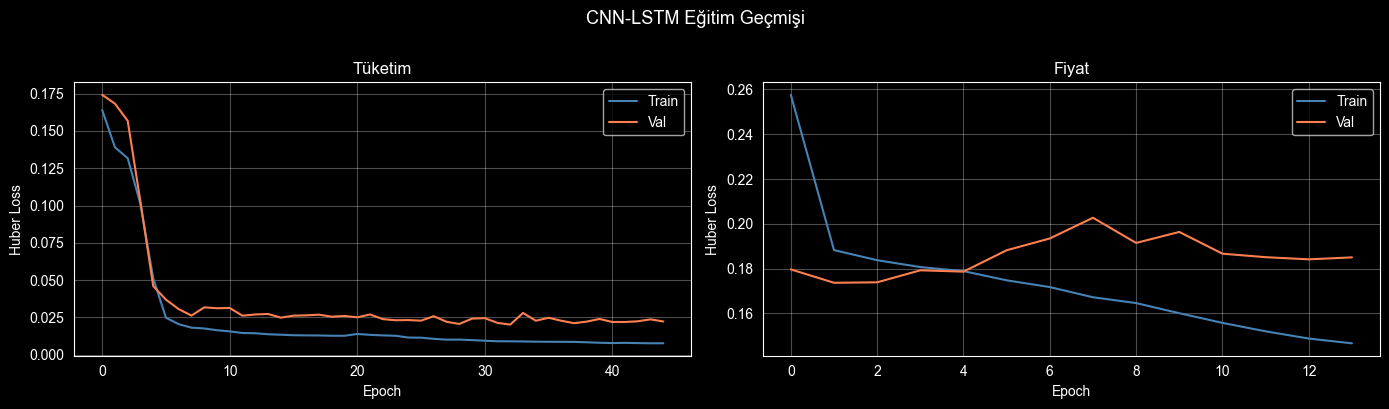

Graf kaydedildi: cnnlstm_training_history.png


In [26]:
def plot_history(histories, labels, title="CNN-LSTM Eğitim Geçmişi"):
    fig, axes = plt.subplots(1, len(histories), figsize=(7 * len(histories), 4))
    if len(histories) == 1:
        axes = [axes]
    for ax, (hist, lbl) in zip(axes, zip(histories, labels)):
        ax.plot(hist['train'], label='Train', color='steelblue', lw=1.5)
        ax.plot(hist['val'],   label='Val',   color='coral',     lw=1.5)
        ax.set_title(f"{lbl}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Huber Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("cnnlstm_training_history.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Graf kaydedildi: cnnlstm_training_history.png")

plot_history([hist_t, hist_f], ["Tüketim", "Fiyat"])

Test Seti Tahmin Görselleştirme (ilk 7 gün)

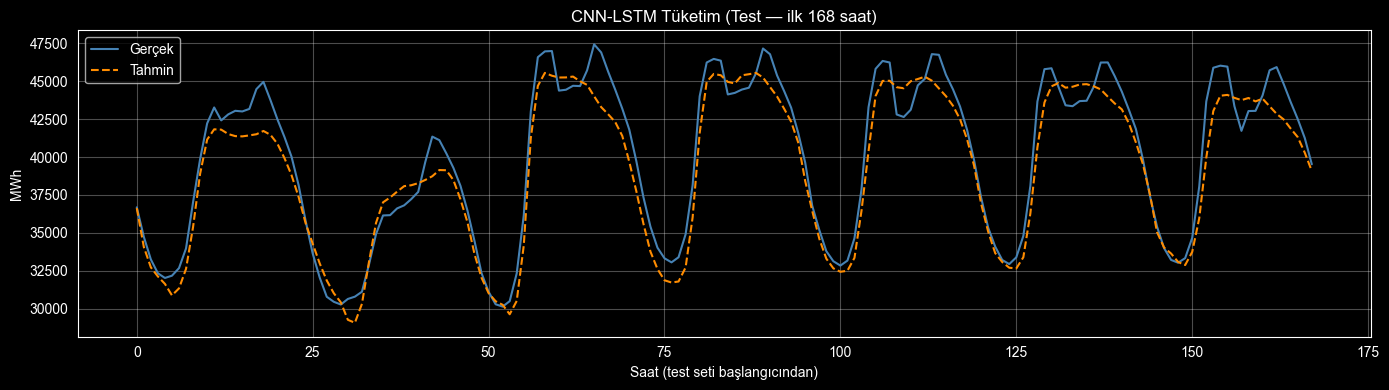

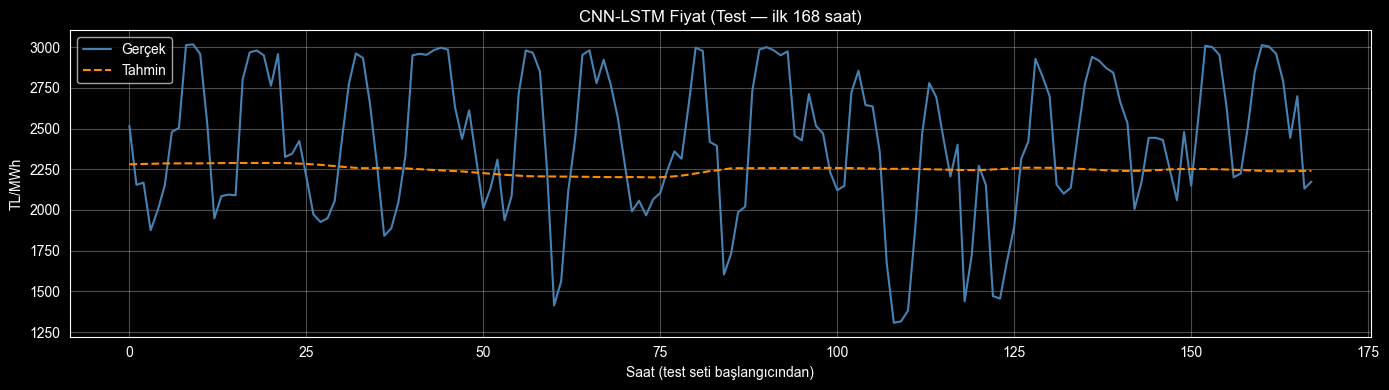

In [27]:
def plot_predictions(res, title, unit, n_hours=168):
    fig, ax = plt.subplots(figsize=(14, 4))
    # Her örnek horizon-adım tahmin içerdiğinden ilk adımı (h=0) al
    p = res['preds'][:n_hours, 0]
    t = res['trues'][:n_hours, 0]
    ax.plot(t, label='Gerçek',   color='steelblue', lw=1.5)
    ax.plot(p, label='Tahmin',   color='darkorange', lw=1.5, ls='--')
    ax.set_title(title)
    ax.set_xlabel("Saat (test seti başlangıcından)")
    ax.set_ylabel(unit)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"cnnlstm_pred_{title[:7].replace(' ','_')}.png"
    plt.savefig(fname, dpi=120)
    plt.show()

plot_predictions(res_t, "CNN-LSTM Tüketim (Test — ilk 168 saat)", "MWh")
plot_predictions(res_f, "CNN-LSTM Fiyat (Test — ilk 168 saat)",   "TL/MWh")

TEMPORAL FUSION TRANSFORMER (TFT)

TimeSeriesDataSet Hazırlama

In [28]:
def tft_loader(ds, train=True):
    return ds.to_dataloader(
        train=train,
        batch_size=256,        # 128 → 256 (T4'te 15GB var, kullan)
        num_workers=4,         # 0 → 4 (Colab'da multiprocessing çalışır)
        pin_memory=True,       # False → True (GPU varsa hızlandırır)
        drop_last=train,
        persistent_workers=True,  # worker'ları epoch'lar arası canlı tut
    )

In [29]:
KNOWN_FUTURE_REALS = ['saat_sin', 'saat_cos', 'gun_sin', 'gun_cos',
                          'ay_sin', 'ay_cos']
# Kategorik — gelecekte de biliniyor (takvim)
KNOWN_FUTURE_CATS  = ['is_weekend', 'is_holiday']

In [30]:
def prepare_tft_dataset(df_full, df_train, df_val, target,
                        max_enc=LOOKBACK_TUKETIM, max_pred=HORIZON):
    feature_cols = get_feature_cols(target)
    unknown_reals = [
        c for c in feature_cols
        if c not in KNOWN_FUTURE_REALS + KNOWN_FUTURE_CATS
    ] + [target]

    for col in KNOWN_FUTURE_CATS:
        df_full[col] = df_full[col].astype(str)

    training_cutoff = df_train['time_idx'].max()
    val_start_idx   = df_val['time_idx'].min()
    val_cutoff      = df_val['time_idx'].max()
    test_start_idx  = val_cutoff + 1

    train_ds = TimeSeriesDataSet(
        df_full[df_full['time_idx'] <= training_cutoff],
        time_idx='time_idx', target=target, group_ids=['group'],
        max_encoder_length=max_enc, max_prediction_length=max_pred,
        time_varying_known_reals=KNOWN_FUTURE_REALS,
        time_varying_known_categoricals=KNOWN_FUTURE_CATS,
        time_varying_unknown_reals=unknown_reals,
        target_normalizer=GroupNormalizer(groups=['group'], transformation='softplus'),
        add_relative_time_idx=True, add_target_scales=True,
        add_encoder_length=True, allow_missing_timesteps=False,
    )

    # Sadece val pencerelerini üret: encoder için LOOKBACK kadar geriye git
    val_context_start = max(0, val_start_idx - max_enc)
    val_ds = TimeSeriesDataSet.from_dataset(
        train_ds,
        df_full[
            (df_full['time_idx'] >= val_context_start) &
            (df_full['time_idx'] <= val_cutoff)
        ],
        predict=False, stop_randomization=True)

    # Sadece test pencerelerini üret
    test_context_start = max(0, test_start_idx - max_enc)
    test_ds = TimeSeriesDataSet.from_dataset(
        train_ds,
        df_full[df_full['time_idx'] >= test_context_start],
        predict=False, stop_randomization=True)

    return train_ds, val_ds, test_ds

In [31]:
# Tüketim
tft_train_t, tft_val_t, tft_test_t = prepare_tft_dataset(
    df_tuketim, train_t, val_t, 'tuketim_mwh')

# Fiyat
tft_train_f, tft_val_f, tft_test_f = prepare_tft_dataset(
    df_fiyat, train_f, val_f, 'fiyat_tl',
    max_enc=LOOKBACK_FIYAT)   # 168

# Loaderlar
tft_tr_loader_t = tft_loader(tft_train_t, train=True)
tft_vl_loader_t = tft_loader(tft_val_t,   train=False)   # eğitimde val için
tft_te_loader_t = tft_loader(tft_test_t,  train=False)   # değerlendirmede test için

tft_tr_loader_f = tft_loader(tft_train_f, train=True)
tft_vl_loader_f = tft_loader(tft_val_f,   train=False)
tft_te_loader_f = tft_loader(tft_test_f,  train=False)

print(f"\nTFT DataSet oluşturuldu.")
print(f"  Tüketim train örnek sayısı: {len(tft_train_t):,}")
print(f"  Fiyat   train örnek sayısı: {len(tft_train_f):,}")


TFT DataSet oluşturuldu.
  Tüketim train örnek sayısı: 26,017
  Fiyat   train örnek sayısı: 17,161


TFT Model Tanımı & Eğitimi

In [32]:
def build_tft_model(dataset):
    return TemporalFusionTransformer.from_dataset(
        dataset,
        learning_rate=3e-3,
        hidden_size=32,              # model kapasitesi (küçük → overfitting azalır)
        attention_head_size=2,
        dropout=0.15,                # attention & FF dropout
        hidden_continuous_size=16,
        loss=QuantileLoss(),         # 7 kantil → belirsizlik tahmini
        log_interval=10,
        reduce_on_plateau_patience=5,
        weight_decay=WEIGHT_DECAY,
    )

In [33]:
def train_tft_model(train_ds, tr_loader, vt_loader, label, ckpt_dir="tft_ckpts"):
    os.makedirs(ckpt_dir, exist_ok=True)

    model = build_tft_model(train_ds)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTFT [{label}]  Eğitilebilir parametre: {n_params:,}")

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE,
                        mode='min', verbose=True),
        LearningRateMonitor(logging_interval='epoch'),
        ModelCheckpoint(
            dirpath=ckpt_dir,
            filename=f"tft_{label.replace(' ', '_')}_best",
            monitor='val_loss', mode='min', save_top_k=1,
        ),
    ]
    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        gradient_clip_val=0.1,
        callbacks=callbacks,
        enable_progress_bar=True,
        logger=True,
        num_sanity_val_steps=0,
    )

    trainer.fit(model, train_dataloaders=tr_loader, val_dataloaders=vt_loader)

    # En iyi checkpoint'tan yükle
    best_path = trainer.checkpoint_callback.best_model_path
    best_model = TemporalFusionTransformer.load_from_checkpoint(best_path)
    best_model.eval()
    print(f"  En iyi model yüklendi: {best_path}")
    return best_model

print("=== TFT: Tüketim Modeli ===")
tft_tuketim = train_tft_model(tft_train_t, tft_tr_loader_t, tft_vl_loader_t, "Tüketim")

print("\n=== TFT: Fiyat Modeli ===")
tft_fiyat   = train_tft_model(tft_train_f, tft_tr_loader_f, tft_vl_loader_f, "Fiyat")

=== TFT: Tüketim Modeli ===

TFT [Tüketim]  Eğitilebilir parametre: 122,407


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      4 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    768 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 48.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 14.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 122 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 122 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 633                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      4 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    768 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 48.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 14.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 122 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 122 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 633                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 229.064
Metric val_loss improved by 28.575 >= min_delta = 0.0. New best score: 200.489
Metric val_loss improved by 17.296 >= min_delta = 0.0. New best score: 183.193
Metric val_loss improved by 3.571 >= min_delta = 0.0. New best score: 179.622
Metric val_loss improved by 3.071 >= min_delta = 0.0. New best score: 176.551
Metric val_loss improved by 4.070 >= min_delta = 0.0. New best score: 172.481
Metric val_loss improved by 0.844 >= min_delta = 0.0. New best score: 171.637
Metric val_loss improved by 4.177 >= min_delta = 0.0. New best score: 167.460
Monitored metric val_loss did not improve in the last 12 records. Best score: 167.460. Signaling Trainer to stop.


  En iyi model yüklendi: C:\Users\kerem\Desktop\EnerjiSon\Modeller\tft_ckpts\tft_Fiyat_best-v2.ckpt


TFT Değerlendirme

In [34]:
def evaluate_tft(model, loader, label=""):
    """
    DÜZELTİLMİŞ: Medyan kantil indeksi dinamik olarak hesaplanıyor.
    """
    raw = model.predict(loader, return_y=True, mode="quantiles")
    preds_all = raw.output
    trues_all = raw.y[0]

    # ← DÜZELTİLDİ: Sabit idx=3 yerine dinamik medyan indeksi
    n_quantiles = preds_all.shape[-1]
    median_idx  = n_quantiles // 2   # [0.02,0.1,0.25,0.5,0.75,0.9,0.98] → idx=3
    preds = preds_all[:, :, median_idx].detach().cpu().numpy()
    trues = trues_all.detach().cpu().numpy()

    rmse  = np.sqrt(mean_squared_error(trues.ravel(), preds.ravel()))
    mae   = mean_absolute_error(trues.ravel(), preds.ravel())
    smape = 100 * np.mean(
        2 * np.abs(preds - trues) /
        (np.abs(preds) + np.abs(trues) + 1e-8))
    nrmse = rmse / (trues.max() - trues.min() + 1e-8)

    lower = preds_all[:, :, 1].detach().cpu().numpy()
    upper = preds_all[:, :, -2].detach().cpu().numpy()
    pi_width = (upper - lower).mean()

    if label:
        print(f"  [{label}]  RMSE: {rmse:>10.2f} | MAE: {mae:>10.2f} | "
              f"sMAPE: {smape:>6.2f}% | NRMSE: {nrmse:.4f} ({nrmse*100:.2f}%) | "
              f"PI_width(80%): {pi_width:.2f}")

    return dict(RMSE=rmse, MAE=mae, sMAPE=smape, NRMSE=nrmse,
                preds=preds, trues=trues, lower=lower, upper=upper)

print("\n=== TFT Test Sonuçları ===")
# evaluate_tft çağrımlarını şöyle değiştir:
tft_res_t = evaluate_tft(tft_tuketim, tft_te_loader_t, "Tüketim (MWh)")
tft_res_f = evaluate_tft(tft_fiyat,   tft_te_loader_f, "Fiyat   (TL) ")


=== TFT Test Sonuçları ===


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn

  [Tüketim (MWh)]  RMSE:    1612.85 | MAE:    1164.08 | sMAPE:   2.85% | NRMSE: 0.0423 (4.23%) | PI_width(80%): 2224.77
  [Fiyat   (TL) ]  RMSE:     691.52 | MAE:     507.29 | sMAPE:  24.44% | NRMSE: 0.1981 (19.81%) | PI_width(80%): 1139.01


Karşılaştırma Tablosu

In [35]:
print("\n" + "=" * 75)
print(f"{'Model':<26} {'RMSE':>10} {'MAE':>10} {'sMAPE':>9} {'NRMSE%':>8}")
print("-" * 75)
rows = [
    ("CNN-LSTM Tüketim (MWh)", res_t),
    ("TFT      Tüketim (MWh)", tft_res_t),
    ("CNN-LSTM Fiyat   (TL)",  res_f),
    ("TFT      Fiyat   (TL)",  tft_res_f),
]
for name, r in rows:
    print(f"  {name:<24} {r['RMSE']:>10.1f} {r['MAE']:>10.1f} "
          f"{r['sMAPE']:>8.2f}% {r['NRMSE']*100:>7.2f}%")  # DÜZELTME: *100 ve % eklendi
print("=" * 75)


Model                            RMSE        MAE     sMAPE   NRMSE%
---------------------------------------------------------------------------
  CNN-LSTM Tüketim (MWh)       1970.4     1420.3     3.57%    5.17%
  TFT      Tüketim (MWh)       1612.9     1164.1     2.85%    4.23%
  CNN-LSTM Fiyat   (TL)         812.2      557.8    25.79%   23.26%
  TFT      Fiyat   (TL)         691.5      507.3    24.44%   19.81%


TFT Değişken Önemi

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


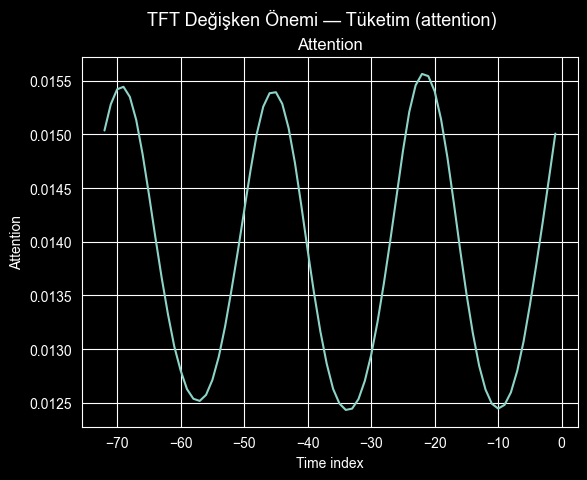

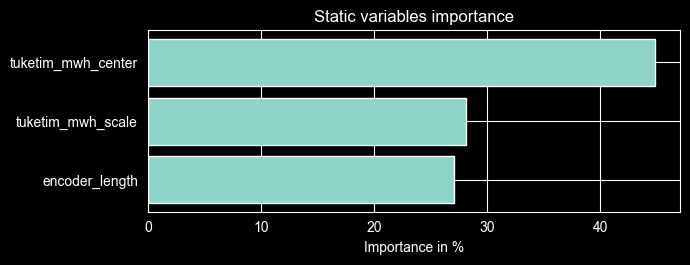

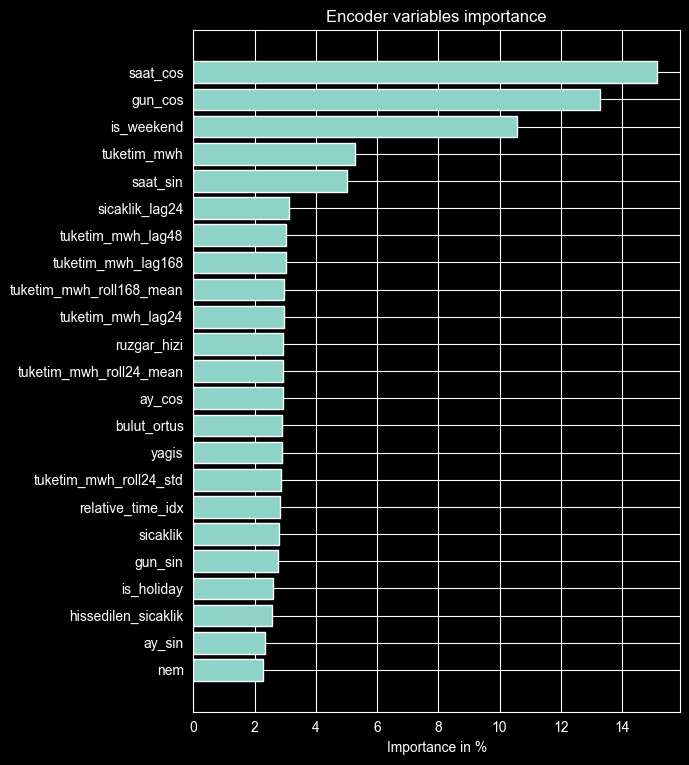

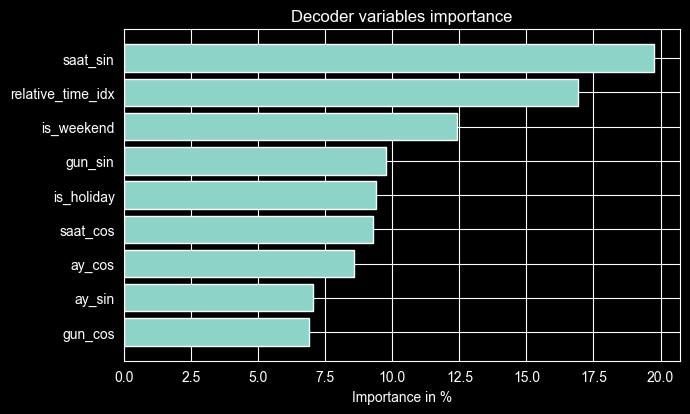

Kaydedildi: tft_importance_Tüketim_attention.png


<Figure size 640x480 with 0 Axes>

Kaydedildi: tft_importance_Tüketim_static_variables.png


<Figure size 640x480 with 0 Axes>

Kaydedildi: tft_importance_Tüketim_encoder_variables.png


<Figure size 640x480 with 0 Axes>

Kaydedildi: tft_importance_Tüketim_decoder_variables.png


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


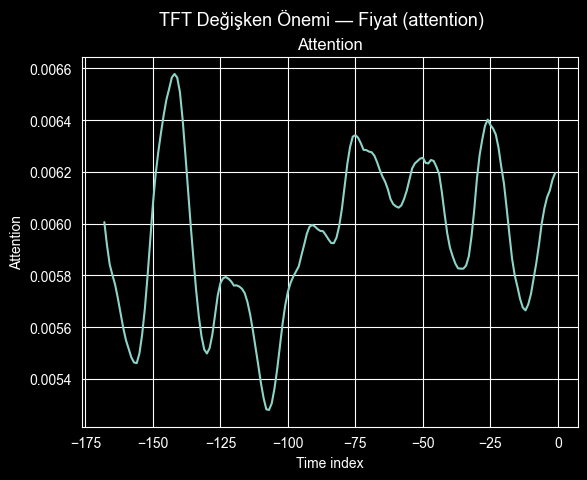

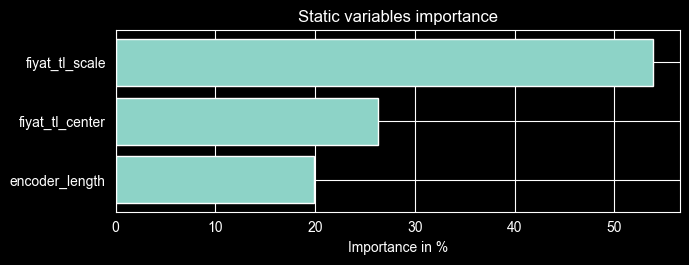

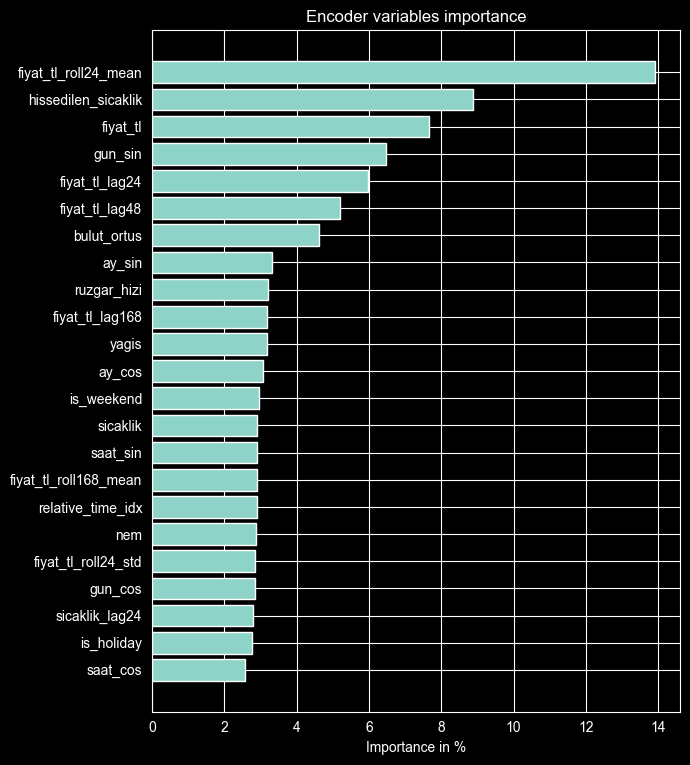

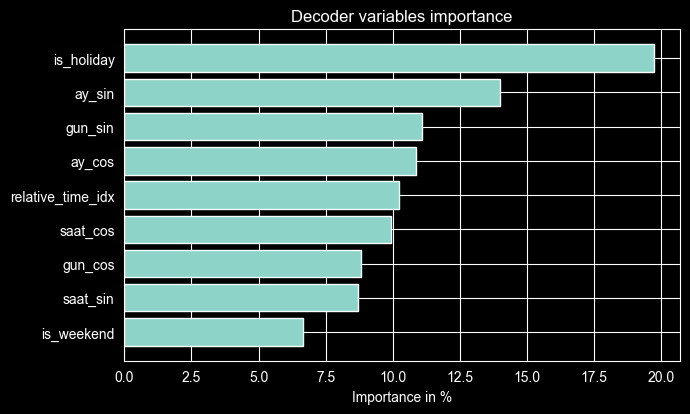

Kaydedildi: tft_importance_Fiyat_attention.png


<Figure size 640x480 with 0 Axes>

Kaydedildi: tft_importance_Fiyat_static_variables.png


<Figure size 640x480 with 0 Axes>

Kaydedildi: tft_importance_Fiyat_encoder_variables.png


<Figure size 640x480 with 0 Axes>

Kaydedildi: tft_importance_Fiyat_decoder_variables.png


In [36]:
def plot_variable_importance(model, train_dataset, df_full, label, n_samples=200):
    # Rastgele değil, son n_samples satırı al (ardışık → zaman sürekliliği korunur)
    df_sample = df_full.tail(n_samples).copy()

    small_dataset = TimeSeriesDataSet.from_dataset(
        train_dataset, df_sample, stop_randomization=True,
        allow_missing_timesteps=True   # güvenlik için ekle
    )

    small_loader = small_dataset.to_dataloader(
        train=False, batch_size=16, num_workers=0, persistent_workers=False,
    )

    with torch.no_grad():
        raw_predictions = model.predict(small_loader, mode="raw", return_x=True)

    interpretation = model.interpret_output(raw_predictions.output, reduction='mean')
    del raw_predictions
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    figs = model.plot_interpretation(interpretation)
    for fig_name, fig in figs.items():
        fig.suptitle(f"TFT Değişken Önemi — {label} ({fig_name})", fontsize=13)
        plt.tight_layout()
        fname = f"tft_importance_{label[:7].replace(' ','_')}_{fig_name}.png"
        fig.savefig(fname, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f"Kaydedildi: {fname}")

    del interpretation
    import gc; gc.collect()

plot_variable_importance(tft_tuketim, tft_train_t, df_tuketim, "Tüketim", n_samples=300)
plot_variable_importance(tft_fiyat,   tft_train_f, df_fiyat,   "Fiyat",   n_samples=300)

TFT Tahmin Aralığı Görselleştirme

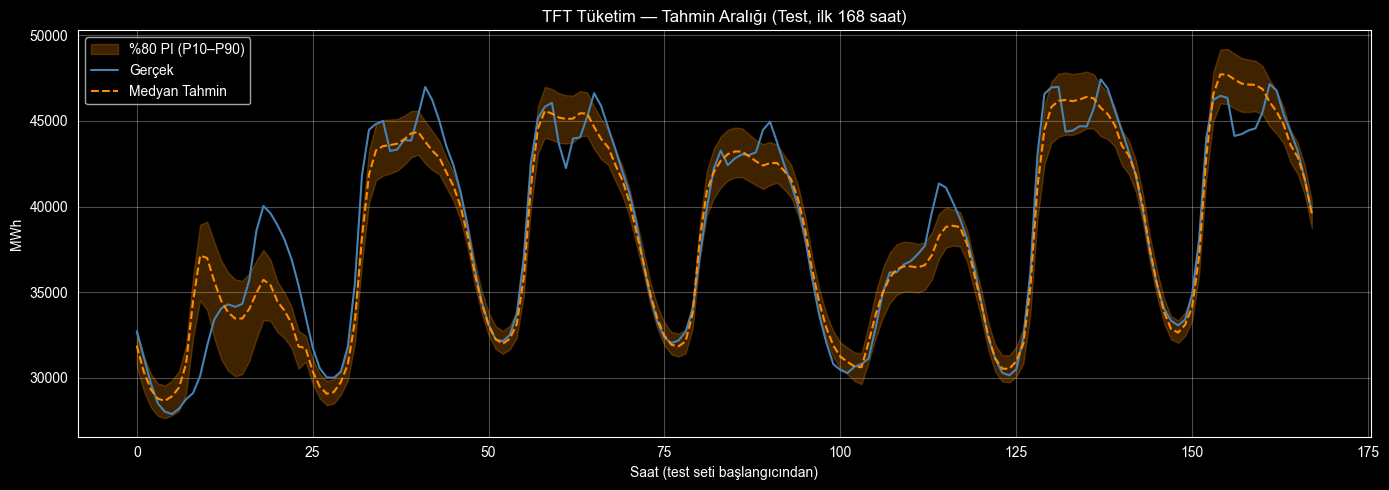

Graf kaydedildi: tft_pred_TFT_Tüketi.png


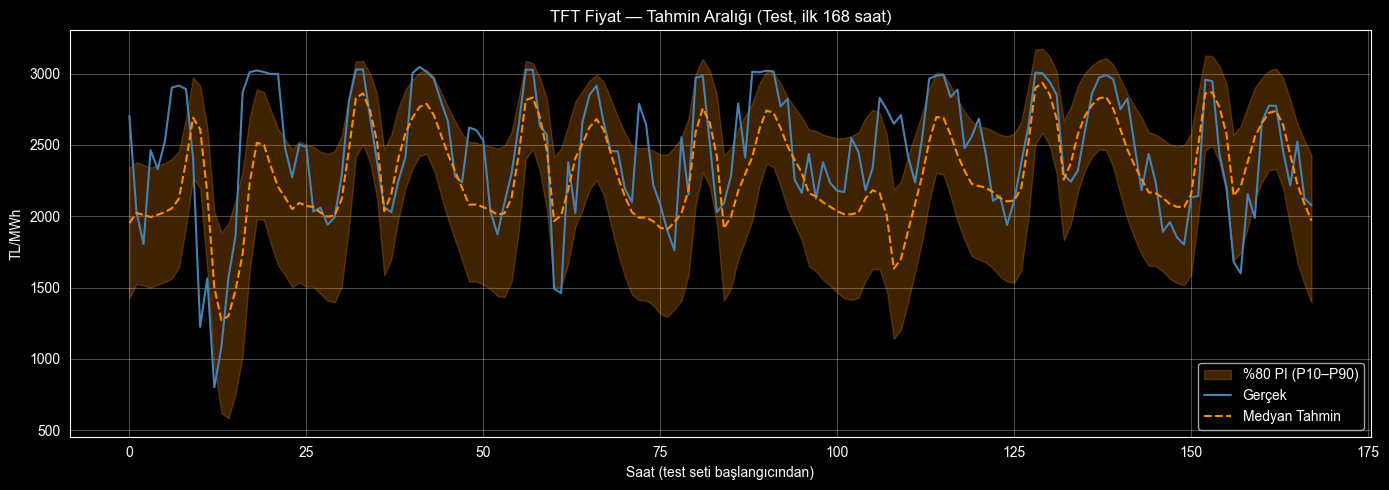

Graf kaydedildi: tft_pred_TFT_Fiyat_.png


In [37]:
def plot_tft_with_intervals(res, title, unit, n_hours=168):
    fig, ax = plt.subplots(figsize=(14, 5))
    t = res['trues'][:n_hours, 0]
    p = res['preds'][:n_hours, 0]
    lo = res['lower'][:n_hours, 0]
    hi = res['upper'][:n_hours, 0]

    ax.fill_between(range(n_hours), lo, hi,
                    alpha=0.25, color='darkorange', label='%80 PI (P10–P90)')
    ax.plot(t, color='steelblue',   lw=1.5, label='Gerçek')
    ax.plot(p, color='darkorange',  lw=1.5, ls='--', label='Medyan Tahmin')
    ax.set_title(title)
    ax.set_xlabel("Saat (test seti başlangıcından)")
    ax.set_ylabel(unit)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"tft_pred_{title[:10].replace(' ','_')}.png"
    plt.savefig(fname, dpi=120)
    plt.show()
    print(f"Graf kaydedildi: {fname}")

plot_tft_with_intervals(tft_res_t, "TFT Tüketim — Tahmin Aralığı (Test, ilk 168 saat)", "MWh")
plot_tft_with_intervals(tft_res_f, "TFT Fiyat — Tahmin Aralığı (Test, ilk 168 saat)",   "TL/MWh")